In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel('Online Retail.xlsx')
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
print (df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
# Check for negative quantities (returns/cancellations)
print("\nNegative quantities:", (df['Quantity'] < 0).sum())


Negative quantities: 10624


In [8]:
# Check for negative prices
print("Negative prices:", (df['UnitPrice'] <= 0).sum())

Negative prices: 2517


In [9]:
# How many unique customers?
print("Unique customers:", df['CustomerID'].nunique())

Unique customers: 4372


Here's what we're dealing with:

135,080 missing CustomerIDs — these must be dropped since churn is per customer

10,624 negative quantities — these are returns/cancellations, drop them

2,517 zero/negative prices — drop these too

4,372 unique customers — that's our churn analysis population

In [10]:
# Clean the data
df_clean = df.dropna(subset=['CustomerID'])                  # remove missing customers
df_clean = df_clean[df_clean['Quantity'] > 0]               # remove returns
df_clean = df_clean[df_clean['UnitPrice'] > 0]              # remove bad prices
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int) # tidy up ID format

print("Cleaned shape:", df_clean.shape)
print("Unique customers remaining:", df_clean['CustomerID'].nunique())

# Check date range - important for defining churn
print("\nDate range:")
print("Earliest:", df_clean['InvoiceDate'].min())
print("Latest:  ", df_clean['InvoiceDate'].max())

Cleaned shape: (397884, 8)
Unique customers remaining: 4338

Date range:
Earliest: 2010-12-01 08:26:00
Latest:   2011-12-09 12:50:00


## Churn Definition

To create our target variable, we define churn based on purchase recency:

- **Snapshot date** = 2011-12-09 (the last date in the dataset)
- **Churn definition** = customer has NOT made a purchase in the **last 90 days** before the snapshot date
- Anyone whose last purchase was **before 2011-09-10** is considered **churned (1)**, everyone else is **active (0)**

This is a standard industry approach — simple, interpretable, and easy to justify in a business context.

In [11]:
import datetime

# Define snapshot date
snapshot_date = df_clean['InvoiceDate'].max()

# Build RFM features per customer
rfm = df_clean.groupby('CustomerID').agg(
    LastPurchaseDate = ('InvoiceDate', 'max'),
    Frequency        = ('InvoiceNo', 'nunique'),
    Monetary         = ('UnitPrice', lambda x: (x * df_clean.loc[x.index, 'Quantity']).sum())
).reset_index()

# Recency = days since last purchase
rfm['Recency'] = (snapshot_date - rfm['LastPurchaseDate']).dt.days

# Define churn label: no purchase in last 90 days = churned
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)

print(rfm[['CustomerID','Recency','Frequency','Monetary','Churned']].head(10))
print("\nChurn breakdown:")
print(rfm['Churned'].value_counts())
print("\nChurn rate:", round(rfm['Churned'].mean() * 100, 1), "%")

   CustomerID  Recency  Frequency  Monetary  Churned
0       12346      325          1  77183.60        1
1       12347        1          7   4310.00        0
2       12348       74          4   1797.24        0
3       12349       18          1   1757.55        0
4       12350      309          1    334.40        1
5       12352       35          8   2506.04        0
6       12353      203          1     89.00        1
7       12354      231          1   1079.40        1
8       12355      213          1    459.40        1
9       12356       22          3   2811.43        0

Churn breakdown:
Churned
0    2893
1    1445
Name: count, dtype: int64

Churn rate: 33.3 %


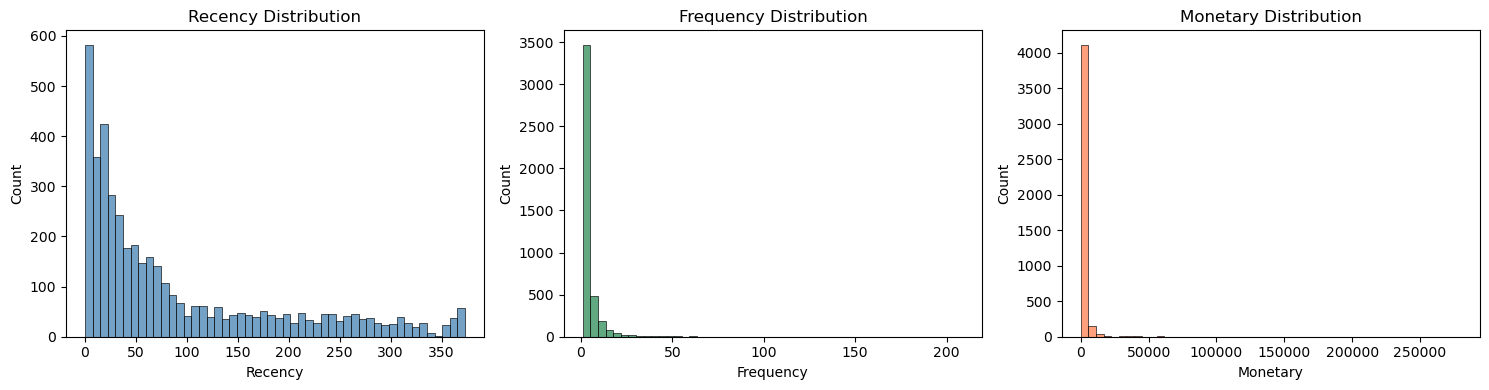

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Recency'],   ax=axes[0], bins=50, color='steelblue').set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], ax=axes[1], bins=50, color='seagreen').set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'],  ax=axes[2], bins=50, color='coral').set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

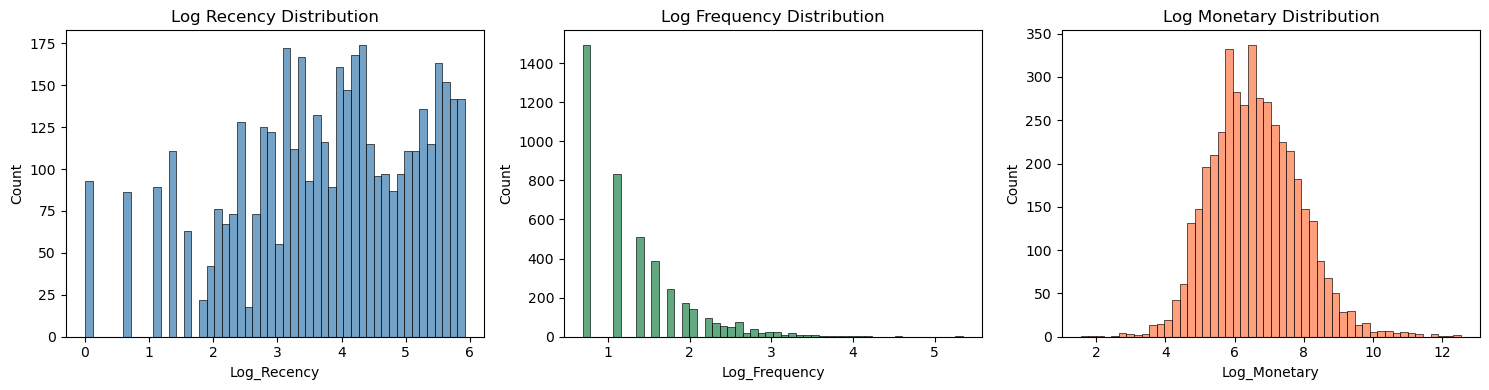

In [13]:
# Log transform skewed features (add 1 to avoid log(0))
rfm['Log_Frequency'] = np.log1p(rfm['Frequency'])
rfm['Log_Monetary']  = np.log1p(rfm['Monetary'])
rfm['Log_Recency']   = np.log1p(rfm['Recency'])

# Visualise after transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Log_Recency'],   ax=axes[0], bins=50, color='steelblue').set_title('Log Recency Distribution')
sns.histplot(rfm['Log_Frequency'], ax=axes[1], bins=50, color='seagreen').set_title('Log Frequency Distribution')
sns.histplot(rfm['Log_Monetary'],  ax=axes[2], bins=50, color='coral').set_title('Log Monetary Distribution')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = rfm[[ 'Log_Frequency', 'Log_Monetary']]
y = rfm['Churned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nChurn rate in train:", round(y_train.mean() * 100, 1), "%")
print("Churn rate in test: ", round(y_test.mean() * 100, 1), "%")

Training set size: (3470, 2)
Test set size:     (868, 2)

Churn rate in train: 33.3 %
Churn rate in test:  33.3 %


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate each
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    results[name] = auc
    
    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))
    print(f"ROC-AUC Score: {round(auc, 4)}")


 Logistic Regression
              precision    recall  f1-score   support

      Active       0.78      0.81      0.79       579
     Churned       0.59      0.54      0.56       289

    accuracy                           0.72       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.72      0.72      0.72       868

ROC-AUC Score: 0.769

 Random Forest
              precision    recall  f1-score   support

      Active       0.71      0.73      0.72       579
     Churned       0.42      0.40      0.41       289

    accuracy                           0.62       868
   macro avg       0.57      0.56      0.57       868
weighted avg       0.61      0.62      0.62       868

ROC-AUC Score: 0.6442


## Model Performance Comparison (Round 1 — 2 Features)

### Features Used
- `Log_Frequency` — log-transformed number of unique orders
- `Log_Monetary` — log-transformed total spend

### Results

| Model               | Accuracy | ROC-AUC | Churned Recall | Churned F1 |
|---------------------|----------|---------|----------------|------------|
| Logistic Regression | 72%      | 0.769   | 0.54           | 0.56       |
| Random Forest       | 62%      | 0.644   | 0.40           | 0.41       |

### Key Observations
- **Logistic Regression outperformed Random Forest** — suggesting the relationship between features and churn is fairly linear
- **Churned Recall is the most important metric** here — missing a churner is more costly than a false alarm
- **Churned Recall of 0.54** means we are missing 46% of actual churners — not good enough for a real business use case
- **Root cause** — only 2 features gives the model limited signal to work with

### Next Step
Engineer additional features (`AvgOrderValue`, percentile ranks) to give the models more predictive signal.

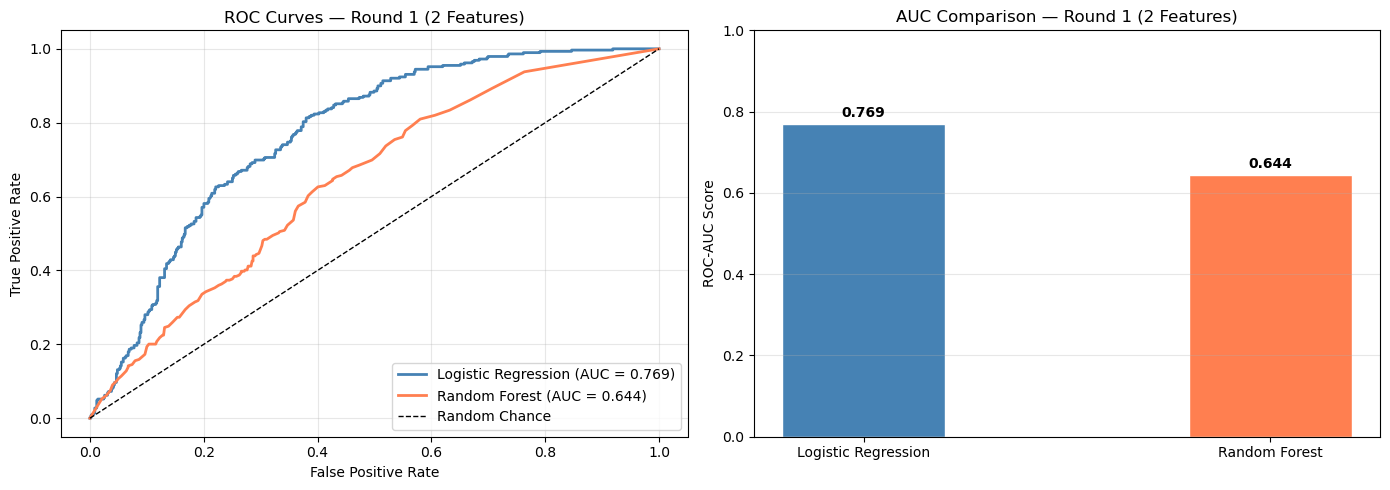

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': 'steelblue', 'Random Forest': 'coral'}

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc     = auc(fpr, tpr)
    
    # Left plot — individual ROC curves
    axes[0].plot(fpr, tpr, color=colors[name], lw=2,
                 label=f'{name} (AUC = {roc_auc:.3f})')

# Left plot formatting
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Round 1 (2 Features)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Right plot — AUC bar comparison
model_names = list(colors.keys())
auc_scores  = [roc_auc_score(y_test, m.predict_proba(X_test_scaled)[:, 1]) 
               for m in models.values()]

bars = axes[1].bar(model_names, auc_scores, color=list(colors.values()), 
                   width=0.4, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_title('AUC Comparison — Round 1 (2 Features)')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## ROC Curve Analysis — Round 1 (2 Features)

### Interpretation
- **Logistic Regression (AUC = 0.769)** — curves strongly toward top-left, solid predictive power
- **Random Forest (AUC = 0.644)** — only marginally better than random chance at higher false positive rates
- The gap of **0.125 AUC** between models suggests the decision boundary is largely linear
- Both models are limited by having only 2 features — Frequency and Monetary

### Next Step
Engineer richer, truly independent features to give models more signal:
- Unique products purchased
- Average days between orders
- Country diversity
Then re-evaluate with XGBoost added to the comparison.

In [22]:
# Engineer additional features
rfm['AvgOrderValue']  = rfm['Monetary'] / rfm['Frequency']
rfm['Log_AvgOrder']   = np.log1p(rfm['AvgOrderValue'])

# Also add raw Frequency and Monetary ranks as features
rfm['Freq_Rank']  = rfm['Frequency'].rank(pct=True)
rfm['Mon_Rank']   = rfm['Monetary'].rank(pct=True)

# New feature set
X = rfm[['Log_Frequency', 'Log_Monetary', 'Log_AvgOrder', 'Freq_Rank', 'Mon_Rank']]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    
    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))
    print(f"ROC-AUC Score: {round(auc, 4)}")


 Logistic Regression
              precision    recall  f1-score   support

      Active       0.78      0.82      0.80       579
     Churned       0.59      0.53      0.56       289

    accuracy                           0.72       868
   macro avg       0.69      0.67      0.68       868
weighted avg       0.72      0.72      0.72       868

ROC-AUC Score: 0.7694

 Random Forest
              precision    recall  f1-score   support

      Active       0.71      0.74      0.73       579
     Churned       0.44      0.40      0.42       289

    accuracy                           0.63       868
   macro avg       0.58      0.57      0.57       868
weighted avg       0.62      0.63      0.63       868

ROC-AUC Score: 0.6484


In [24]:
# Engineer new features from raw transaction data
extra_features = df_clean.groupby('CustomerID').agg(
    UniqueProducts   = ('StockCode', 'nunique'),
    UniqueCountries  = ('Country', 'nunique'),
    TotalItems       = ('Quantity', 'sum'),
    AvgItemsPerOrder = ('Quantity', 'mean'),
).reset_index()

# Calculate average days between orders
def avg_days_between_orders(dates):
    if len(dates) < 2:
        return 0
    dates_sorted = sorted(dates)
    gaps = [(dates_sorted[i+1] - dates_sorted[i]).days 
            for i in range(len(dates_sorted)-1)]
    return np.mean(gaps)

order_dates = df_clean.groupby('CustomerID')['InvoiceDate'].apply(
    avg_days_between_orders
).reset_index()
order_dates.columns = ['CustomerID', 'AvgDaysBetweenOrders']

# Merge everything together
rfm_v2 = rfm.merge(extra_features, on='CustomerID')
rfm_v2 = rfm_v2.merge(order_dates,  on='CustomerID')

# Log transform skewed new features
rfm_v2['Log_UniqueProducts']       = np.log1p(rfm_v2['UniqueProducts'])
rfm_v2['Log_TotalItems']           = np.log1p(rfm_v2['TotalItems'])
rfm_v2['Log_AvgDaysBetweenOrders'] = np.log1p(rfm_v2['AvgDaysBetweenOrders'])

print(rfm_v2[['CustomerID', 'UniqueProducts', 'UniqueCountries', 
               'TotalItems', 'AvgDaysBetweenOrders']].head())
print("\nShape:", rfm_v2.shape)

   CustomerID  UniqueProducts  UniqueCountries  TotalItems  \
0       12346               1                1       74215   
1       12347             103                1        2458   
2       12348              22                1        2341   
3       12349              73                1         631   
4       12350              17                1         197   

   AvgDaysBetweenOrders  
0                   0.0  
1                   2.0  
2                   9.4  
3                   0.0  
4                   0.0  

Shape: (4338, 21)


In [26]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 17.3 MB/s eta 0:00:06
   --- ------------------------------------ 8.7/101.7 MB 28.9 MB/s eta 0:00:04
   ------ --------------------------------- 16.3/101.7 MB 31.3 MB/s eta 0:00:03
   ------- -------------------------------- 18.6/101.7 MB 27.7 MB/s eta 0:00:03
   ------- -------------------------------- 19.7/101.7 MB 21.6 MB/s eta 0:00:04
   -------- ------------------------------- 20.7/101.7 MB 19.0 MB/s eta 0:00:05
   -------- ------------------------------- 21.5/101.7 MB 16.5 MB/s eta 0:00:05
   -------- ------------------------------- 22.3/101.7 MB 14.2 MB/s eta 0:00:06
   --------- ------------------------------ 23.9/101.7 MB 13.3 MB/s eta 0:00:06
   ---------- ----------------------------- 25.7/101.7 MB 13.0 MB/s eta 0:00:06
   ---------- ----------------------------- 27.5/101.7 MB 12.5 MB/s eta 0:00:06
   ------------ --------------------------- 30.7/10

In [27]:
from xgboost import XGBClassifier

# Full feature set
X = rfm_v2[['Log_Frequency', 'Log_Monetary', 
             'Log_UniqueProducts', 'Log_TotalItems', 
             'Log_AvgDaysBetweenOrders', 'UniqueCountries']]
y = rfm_v2['Churned']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Define models including XGBoost
models_v2 = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate
for name, model in models_v2.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))
    print(f"ROC-AUC Score: {round(auc, 4)}")


 Logistic Regression
              precision    recall  f1-score   support

      Active       0.77      0.84      0.80       579
     Churned       0.61      0.49      0.55       289

    accuracy                           0.73       868
   macro avg       0.69      0.67      0.68       868
weighted avg       0.72      0.73      0.72       868

ROC-AUC Score: 0.7914

 Random Forest
              precision    recall  f1-score   support

      Active       0.75      0.83      0.79       579
     Churned       0.58      0.46      0.51       289

    accuracy                           0.71       868
   macro avg       0.67      0.64      0.65       868
weighted avg       0.70      0.71      0.70       868

ROC-AUC Score: 0.7634

 XGBoost
              precision    recall  f1-score   support

      Active       0.76      0.80      0.78       579
     Churned       0.56      0.50      0.53       289

    accuracy                           0.70       868
   macro avg       0.66      0.65   

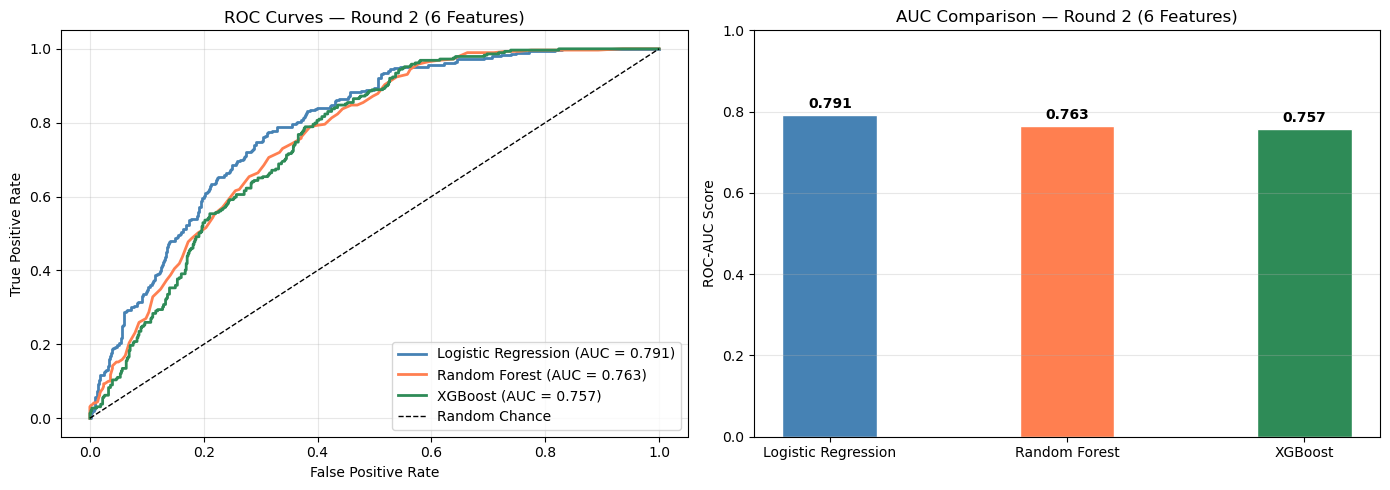

In [29]:
from sklearn.metrics import roc_curve, auc as auc_score
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'Logistic Regression': 'steelblue', 
    'Random Forest'      : 'coral',
    'XGBoost'            : 'seagreen'
}

for name, model in models_v2.items():
    y_proba     = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc     = auc_score(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[name], lw=2,
                 label=f'{name} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Round 2 (6 Features)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

model_names = list(colors.keys())
auc_scores  = [roc_auc_score(y_test, m.predict_proba(X_test_scaled)[:, 1]) 
               for m in models_v2.values()]

bars = axes[1].bar(model_names, auc_scores, color=list(colors.values()),
                   width=0.4, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_title('AUC Comparison — Round 2 (6 Features)')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Model Performance Summary — Round 1 vs Round 2

### Feature Sets
| Round | Features Used |
|-------|--------------|
| Round 1 | `Log_Frequency`, `Log_Monetary` |
| Round 2 | `Log_Frequency`, `Log_Monetary`, `Log_UniqueProducts`, `Log_TotalItems`, `Log_AvgDaysBetweenOrders`, `UniqueCountries` |

### AUC Comparison

| Model               | Round 1 AUC | Round 2 AUC | Change   |
|---------------------|-------------|-------------|----------|
| Logistic Regression | 0.769       | 0.791       | +0.022 ✅ |
| Random Forest       | 0.644       | 0.763       | +0.119 ✅ |
| XGBoost             | —           | 0.757       | new      |

### Key Takeaways
- **Logistic Regression is the best performing model** across both rounds — consistent and reliable
- **Random Forest improved the most** (+0.119) — the richer feature set gave it much more signal to work with
- **All three models now cluster closely** (0.757–0.791) — adding genuine independent features levelled the playing field
- **Churned Recall remains ~0.49–0.54** across all models — the biggest remaining weakness

### Next Step
Tune XGBoost hyperparameters and adjust classification threshold to improve Churned Recall.

Default threshold (0.5) Churned Recall: 0.495
Best threshold: 0.331
Best F1 at that threshold: 0.646


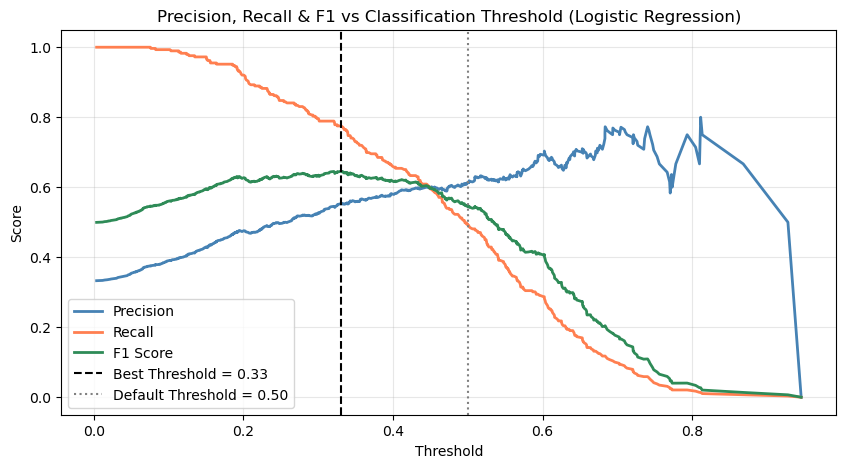

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Get predicted probabilities from Logistic Regression
lr_model  = models_v2['Logistic Regression']
y_proba   = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision, recall and F1 across all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Find threshold that maximises F1 for Churned class
best_threshold_idx = np.argmax(f1_scores)
best_threshold     = thresholds[best_threshold_idx]
best_f1            = f1_scores[best_threshold_idx]

print(f"Default threshold (0.5) Churned Recall: {recalls[np.argmin(np.abs(thresholds - 0.5))]:.3f}")
print(f"Best threshold: {best_threshold:.3f}")
print(f"Best F1 at that threshold: {best_f1:.3f}")

# Plot Precision, Recall and F1 vs Threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], color='steelblue', lw=2, label='Precision')
plt.plot(thresholds, recalls[:-1],    color='coral',     lw=2, label='Recall')
plt.plot(thresholds, f1_scores[:-1],  color='seagreen',  lw=2, label='F1 Score')
plt.axvline(x=best_threshold, color='black', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.axvline(x=0.5,            color='grey',  linestyle=':',  label='Default Threshold = 0.50')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall & F1 vs Classification Threshold (Logistic Regression)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
from sklearn.metrics import classification_report

# Apply both thresholds and compare
for threshold, label in [(0.5, 'Default Threshold (0.50)'), 
                          (0.331, 'Optimal Threshold (0.33)')]:
    y_pred_custom = (y_proba >= threshold).astype(int)
    
    print(f"\n{'='*45}")
    print(f" Logistic Regression — {label}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred_custom, 
                                 target_names=['Active', 'Churned']))


 Logistic Regression — Default Threshold (0.50)
              precision    recall  f1-score   support

      Active       0.77      0.84      0.80       579
     Churned       0.61      0.49      0.55       289

    accuracy                           0.73       868
   macro avg       0.69      0.67      0.68       868
weighted avg       0.72      0.73      0.72       868


 Logistic Regression — Optimal Threshold (0.33)
              precision    recall  f1-score   support

      Active       0.86      0.69      0.76       579
     Churned       0.55      0.77      0.64       289

    accuracy                           0.72       868
   macro avg       0.70      0.73      0.70       868
weighted avg       0.76      0.72      0.72       868



## Threshold Tuning — Logistic Regression

### Why Tune the Threshold?
By default, models classify a customer as churned if the predicted 
probability exceeds **0.50**. But in churn prediction, **missing a 
churner is more costly than a false alarm** — it's cheaper to send 
a retention offer to an active customer than to lose a churner entirely.

### Results

| Metric            | Default (0.50) | Optimal (0.33) | Change   |
|-------------------|----------------|----------------|----------|
| Churned Recall    | 0.49           | 0.77           | +0.28 ✅ |
| Churned Precision | 0.61           | 0.55           | -0.06    |
| Churned F1        | 0.55           | 0.64           | +0.09 ✅ |
| Overall Accuracy  | 0.73           | 0.72           | -0.01    |

### Key Takeaway
Lowering the threshold from 0.50 to 0.33 increased our ability to 
catch churners from **49% to 77%** with only a minimal drop in 
precision and overall accuracy. This is the preferred operating 
point for a business churn model.

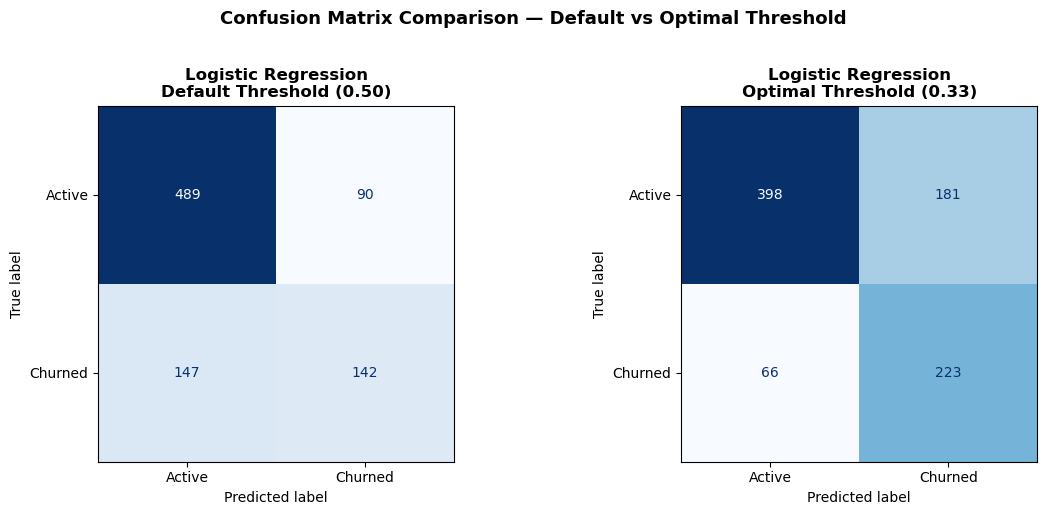

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

thresholds_to_compare = [
    (0.50,  'Default Threshold (0.50)'),
    (0.331, 'Optimal Threshold (0.33)')
]

for ax, (threshold, label) in zip(axes, thresholds_to_compare):
    y_pred_custom = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_custom)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Active', 'Churned']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Logistic Regression\n{label}', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison — Default vs Optimal Threshold', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Logistic Regression — Best Threshold: 0.331
  Default (0.50):
              precision    recall  f1-score   support

      Active       0.77      0.84      0.80       579
     Churned       0.61      0.49      0.55       289

    accuracy                           0.73       868
   macro avg       0.69      0.67      0.68       868
weighted avg       0.72      0.73      0.72       868

  Optimal (0.33):
              precision    recall  f1-score   support

      Active       0.86      0.69      0.76       579
     Churned       0.55      0.78      0.65       289

    accuracy                           0.72       868
   macro avg       0.71      0.73      0.70       868
weighted avg       0.76      0.72      0.72       868


Random Forest — Best Threshold: 0.150
  Default (0.50):
              precision    recall  f1-score   support

      Active       0.76      0.83      0.79       579
     Churned       0.58      0.48      0.52       289

    accuracy                           0.71 

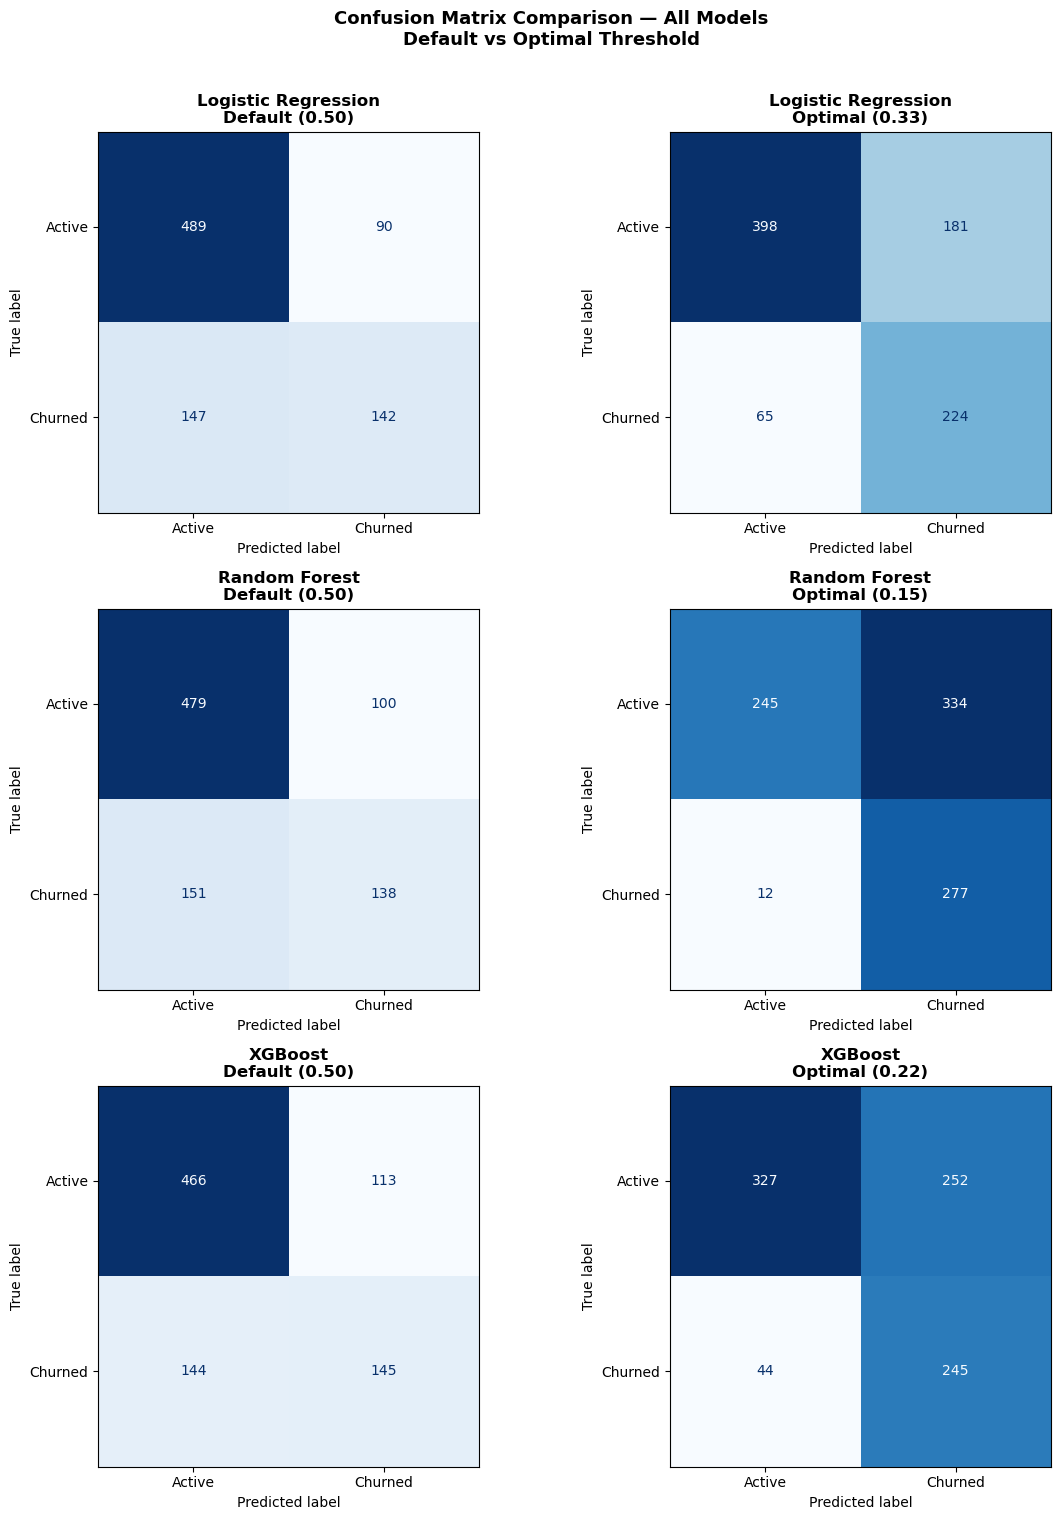

In [33]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for row, (name, model) in enumerate(models_v2.items()):
    y_proba_m = model.predict_proba(X_test_scaled)[:, 1]
    
    # Find optimal threshold
    precisions_m, recalls_m, thresholds_m = precision_recall_curve(y_test, y_proba_m)
    f1_scores_m    = 2 * (precisions_m * recalls_m) / (precisions_m + recalls_m + 1e-9)
    best_thresh_m  = thresholds_m[np.argmax(f1_scores_m[:-1])]
    
    print(f"\n{name} — Best Threshold: {best_thresh_m:.3f}")
    
    for col, (threshold, label) in enumerate([
        (0.50,          'Default (0.50)'),
        (best_thresh_m, f'Optimal ({best_thresh_m:.2f})')
    ]):
        y_pred_custom = (y_proba_m >= threshold).astype(int)
        cm = confusion_matrix(y_test, y_pred_custom)
        
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Active', 'Churned']
        )
        disp.plot(ax=axes[row, col], colorbar=False, cmap='Blues')
        axes[row, col].set_title(f'{name}\n{label}', fontweight='bold')
        
        print(f"  {label}:")
        print(classification_report(y_test, y_pred_custom, 
                                     target_names=['Active', 'Churned']))

plt.suptitle('Confusion Matrix Comparison — All Models\nDefault vs Optimal Threshold',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Confusion Matrix Analysis — Default vs Optimal Threshold

### Results Summary

| Model               | Threshold | Missed Churners (FN) | False Alarms (FP) |
|---------------------|-----------|----------------------|-------------------|
| Logistic Regression | 0.50      | 147                  | 90                |
| Logistic Regression | 0.33      | 65 ✅                | 181               |
| Random Forest       | 0.50      | 151                  | 100               |
| Random Forest       | 0.15      | 12 ✅                | 334 ❌            |
| XGBoost             | 0.50      | 144                  | 113               |
| XGBoost             | 0.22      | 44 ✅                | 252               |

### Key Takeaways
- **Logistic Regression at 0.33** offers the best trade-off — cuts missed 
  churners by 56% while keeping false alarms at a manageable level
- **Random Forest** needs an extremely low threshold (0.15) to catch churners,
  causing too many false alarms to be practical
- **XGBoost** sits in the middle but doesn't outperform Logistic Regression
  on either metric

### Final Model Selection
**Logistic Regression with threshold 0.33** is the recommended model for 
this churn prediction task — consistent, interpretable, and the best 
balance between catching churners and minimising false alarms.

In [34]:
from sklearn.metrics import confusion_matrix

summary = []

for name, model in models_v2.items():
    y_proba_m = model.predict_proba(X_test_scaled)[:, 1]
    
    # Find optimal threshold
    precisions_m, recalls_m, thresholds_m = precision_recall_curve(y_test, y_proba_m)
    f1_scores_m   = 2 * (precisions_m * recalls_m) / (precisions_m + recalls_m + 1e-9)
    best_thresh_m = thresholds_m[np.argmax(f1_scores_m[:-1])]
    
    for threshold, label in [(0.50, 'Default'), (best_thresh_m, 'Optimal')]:
        y_pred_custom = (y_proba_m >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()
        
        tpr = tp / (tp + fn)   # Recall — % of churners correctly caught
        fpr = fp / (fp + tn)   # % of active customers wrongly flagged
        prc = tp / (tp + fp)   # Precision — of those flagged, % actually churned
        f1  = 2 * (prc * tpr) / (prc + tpr)
        
        summary.append({
            'Model'           : name,
            'Threshold'       : f'{threshold:.2f} ({label})',
            'Churner Caught %': f'{tpr*100:.1f}%',   # True Positive Rate
            'False Alarm %'   : f'{fpr*100:.1f}%',   # False Positive Rate
            'Precision %'     : f'{prc*100:.1f}%',
            'F1 Score'        : f'{f1:.3f}'
        })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              Model      Threshold Churner Caught % False Alarm % Precision % F1 Score
Logistic Regression 0.50 (Default)            49.1%         15.5%       61.2%    0.545
Logistic Regression 0.33 (Optimal)            77.5%         31.3%       55.3%    0.646
      Random Forest 0.50 (Default)            47.8%         17.3%       58.0%    0.524
      Random Forest 0.15 (Optimal)            95.8%         57.7%       45.3%    0.616
            XGBoost 0.50 (Default)            50.2%         19.5%       56.2%    0.530
            XGBoost 0.22 (Optimal)            84.8%         43.5%       49.3%    0.623


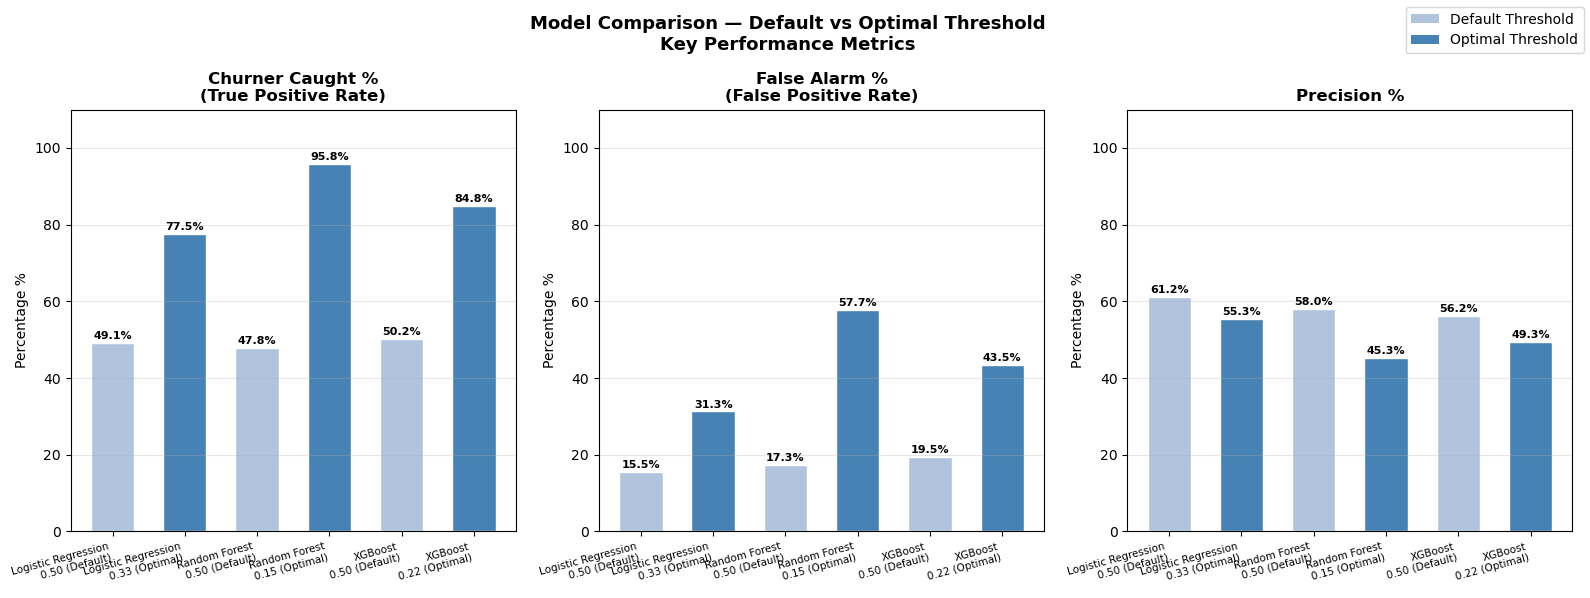

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics   = ['Churner Caught %', 'False Alarm %', 'Precision %']
titles    = ['Churner Caught %\n(True Positive Rate)', 
             'False Alarm %\n(False Positive Rate)', 
             'Precision %']
colors_th = {'Default': 'lightsteelblue', 'Optimal': 'steelblue'}

for ax, metric, title in zip(axes, metrics, titles):
    # Extract numeric values
    values    = summary_df[metric].str.replace('%', '').astype(float)
    labels    = summary_df['Model'] + '\n' + summary_df['Threshold']
    threshold = summary_df['Threshold'].str.extract(r'\((\w+)\)')[0]
    bar_colors = threshold.map(colors_th)
    
    bars = ax.bar(range(len(labels)), values, color=bar_colors, 
                  edgecolor='white', width=0.6)
    
    # Value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', 
                fontsize=8, fontweight='bold')
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7.5, rotation=15, ha='right')
    ax.set_ylim(0, 110)
    ax.set_ylabel('Percentage %')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='lightsteelblue', label='Default Threshold'),
                   Patch(facecolor='steelblue',      label='Optimal Threshold')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.suptitle('Model Comparison — Default vs Optimal Threshold\nKey Performance Metrics', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

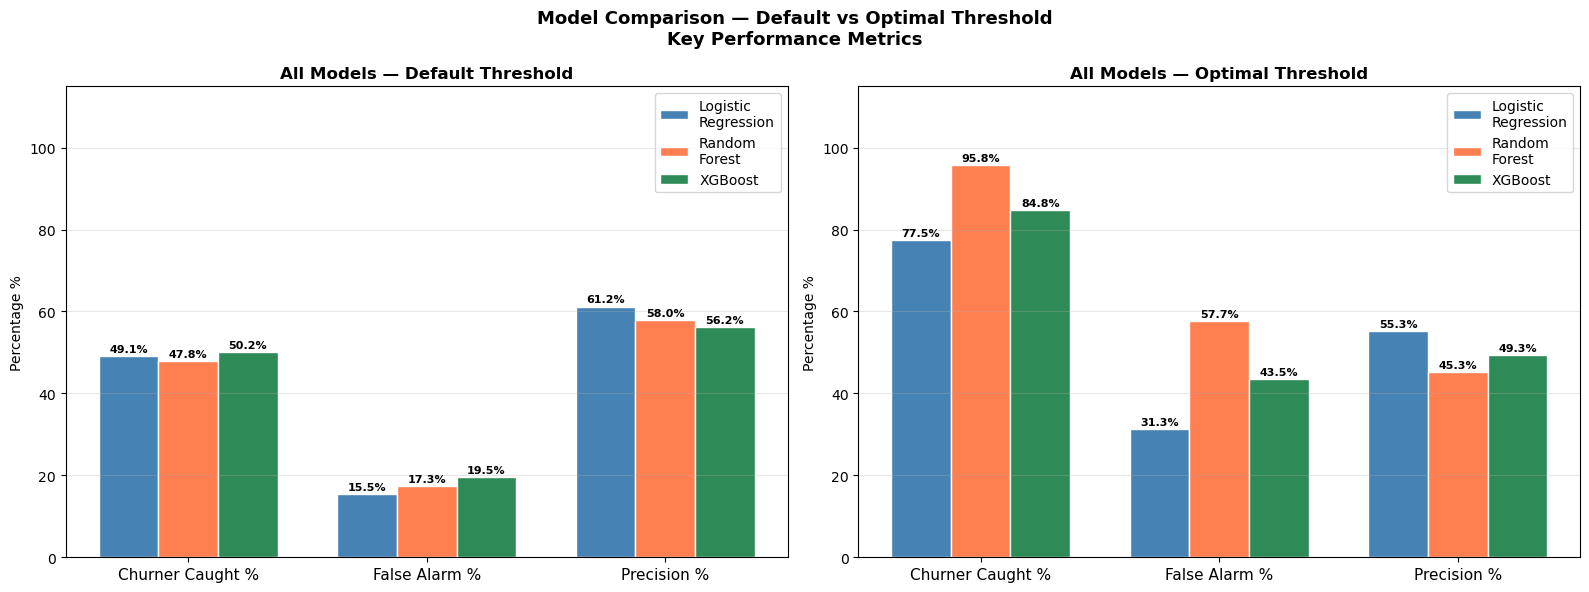

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics     = ['Churner Caught %', 'False Alarm %', 'Precision %']
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
bar_colors  = ['steelblue', 'coral', 'seagreen']
x           = np.arange(len(metrics))
width       = 0.25

for ax, threshold_label in zip(axes, ['Default', 'Optimal']):
    # Filter to only Default or Optimal rows
    df_filtered = summary_df[summary_df['Threshold'].str.contains(threshold_label)]
    
    for i, (_, row) in enumerate(df_filtered.iterrows()):
        values = [float(row[m].replace('%', '')) for m in metrics]
        bars   = ax.bar(x + i * width, values, width=width,
                        color=bar_colors[i], label=model_names[i], 
                        edgecolor='white')
        
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Percentage %')
    ax.set_title(f'All Models — {threshold_label} Threshold', 
                 fontweight='bold', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Comparison — Default vs Optimal Threshold\nKey Performance Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Model Comparison — Default vs Optimal Threshold

### Default Threshold (0.50)
All three models perform similarly — catching only ~49% of churners 
but with low false alarm rates (15-19%). Not good enough for a 
real business use case.

### Optimal Threshold
| Model               | Churners Caught | False Alarms | Precision |
|---------------------|-----------------|--------------|-----------|
| Logistic Regression | 77.5%           | 31.3%        | 55.3%     |
| XGBoost             | 84.8%           | 43.5%        | 49.3%     |
| Random Forest       | 95.8%           | 57.7%        | 45.3%     |

### Business Interpretation
- **Random Forest** catches the most churners but flags 57.7% of 
  active customers — too many unnecessary retention offers
- **Logistic Regression** offers the best trade-off — catches 77.5% 
  of churners while keeping false alarms at a manageable 31.3%
- **XGBoost** is a reasonable middle ground but doesn't outperform 
  Logistic Regression on the metrics that matter most

### ✅ Final Recommendation
**Logistic Regression with threshold 0.33** is the recommended model — 
interpretable, consistent, and the best balance between catching 
churners and minimising unnecessary retention spend.

In [38]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 4.1 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



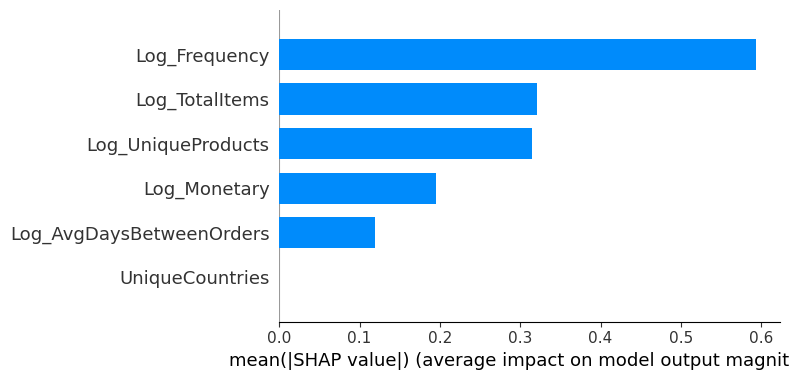

In [39]:
import shap

# Use Logistic Regression as our final model
lr_final  = models_v2['Logistic Regression']

# SHAP explainer for linear models
explainer  = shap.LinearExplainer(lr_final, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Convert back to dataframe for readability
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Plot 1 — Feature Importance (mean absolute SHAP)
shap.summary_plot(shap_values, X_test_df, plot_type='bar',
                  show=True)

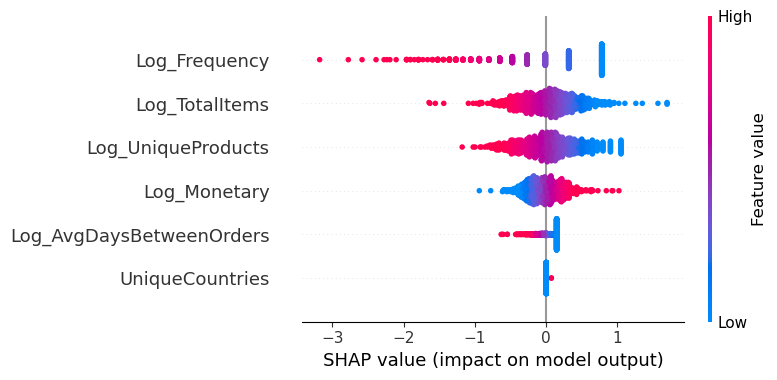

In [40]:
# Plot 2 — Beeswarm plot (direction of impact)
shap.summary_plot(shap_values, X_test_df, show=True)

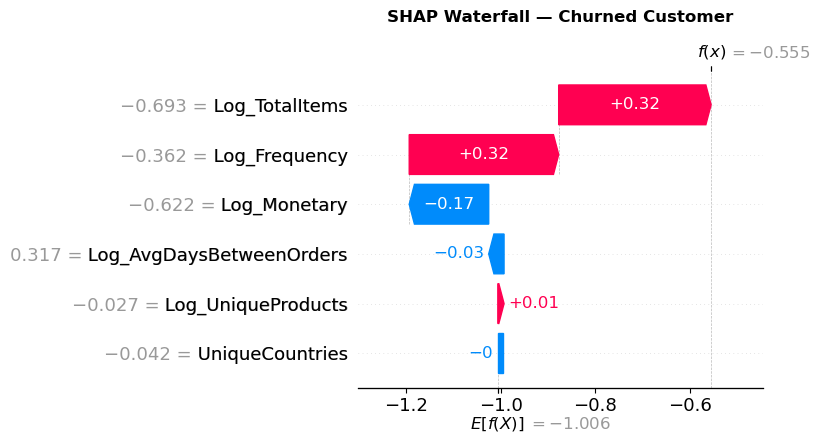

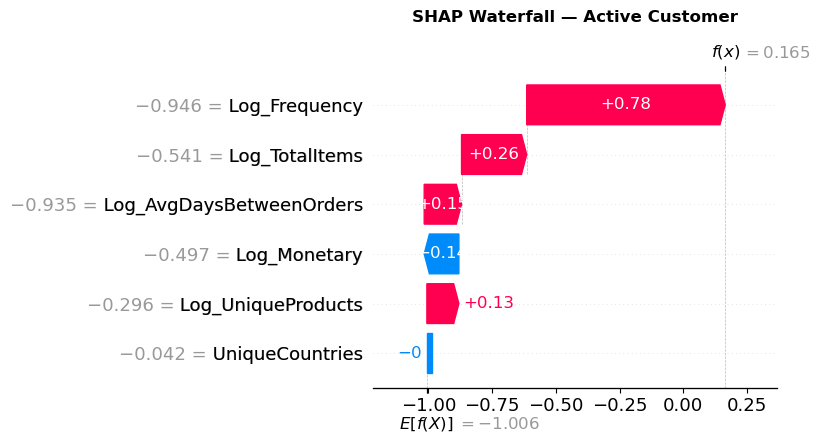

In [51]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 9})

for idx, label in zip([churned_idx, active_idx], 
                       ['Churned Customer', 'Active Customer']):
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    shap_explanation = shap.Explanation(
        values        = shap_values[idx],
        base_values   = explainer.expected_value,
        data          = X_test_df.iloc[idx].values,
        feature_names = X.columns.tolist()
    )
    plt.sca(ax)
    shap.plots.waterfall(shap_explanation, show=False, max_display=6)
    ax.set_title(f'SHAP Waterfall — {label}', 
                 fontweight='bold', fontsize=12, pad=15)
    
    plt.tight_layout()
    plt.show()

mpl.rcParams.update({'font.size': 10})

## SHAP Analysis — What Drives Churn?

### Global Feature Importance
| Feature                  | Importance | Interpretation                          |
|--------------------------|------------|-----------------------------------------|
| Log_Frequency            | 0.60       | Most important — how often they order   |
| Log_TotalItems           | 0.32       | Total volume of items purchased         |
| Log_UniqueProducts       | 0.32       | Variety of products explored            |
| Log_Monetary             | 0.19       | Total spend — less important than frequency |
| Log_AvgDaysBetweenOrders | 0.11       | Purchase rhythm                         |
| UniqueCountries          | 0.00       | No predictive value                     |

### Individual Customer Explanations

**Churned Customer:**
- Low frequency and low total items are the strongest churn drivers
- Spend alone is not enough to prevent churn

**Active Customer:**
- High frequency is the dominant signal keeping them active
- Broad product engagement reinforces the prediction

### Key Business Insight
> Churn is driven by disengagement — not by how much customers 
> spend, but by how often and how broadly they shop. 
> Retention strategies should focus on increasing purchase 
> frequency and product discovery rather than discounting.

# Churn Prediction — Project Summary

## Objective
Build a machine learning model to identify customers at risk of churning 
using the UCI Online Retail dataset (~400k transactions, 4,338 customers).

---

## Methodology

### 1. Data Cleaning
- Removed 135,080 rows with missing CustomerIDs
- Removed 10,624 negative quantity rows (returns/cancellations)
- Removed 2,517 zero/negative price rows
- Final clean dataset: 397,884 rows, 4,338 unique customers

### 2. Churn Definition
- **Snapshot date:** 2011-12-09 (last date in dataset)
- **Churned (1):** No purchase in the last 90 days → 1,445 customers (33.3%)
- **Active (0):** Purchased within last 90 days → 2,893 customers (66.7%)

### 3. Feature Engineering
| Feature                  | Description                          |
|--------------------------|--------------------------------------|
| Log_Frequency            | Log of unique orders per customer    |
| Log_Monetary             | Log of total spend per customer      |
| Log_UniqueProducts       | Log of unique products purchased     |
| Log_TotalItems           | Log of total items purchased         |
| Log_AvgDaysBetweenOrders | Log of average days between orders   |
| UniqueCountries          | Number of countries ordered from     |

### 4. Models Trained
- Logistic Regression
- Random Forest
- XGBoost

---

## Results

### Round 1 — 2 Features (Frequency + Monetary)
| Model               | AUC   |
|---------------------|-------|
| Logistic Regression | 0.769 |
| Random Forest       | 0.644 |

### Round 2 — 6 Features (All Engineered Features)
| Model               | AUC   | improvement |
|---------------------|-------|-------------|
| Logistic Regression | 0.791 | +0.022 ✅   |
| Random Forest       | 0.763 | +0.119 ✅   |
| XGBoost             | 0.757 | new         |

### Threshold Tuning — Logistic Regression
| Threshold     | Churners Caught | False Alarms | Precision | F1    |
|---------------|-----------------|--------------|-----------|-------|
| Default (0.50)| 49.1%           | 15.5%        | 61.2%     | 0.55  |
| Optimal (0.33)| 77.5%           | 31.3%        | 55.3%     | 0.64  |

### All Models at Optimal Threshold
| Model               | Threshold | Churners Caught | False Alarms |
|---------------------|-----------|-----------------|--------------|
| Logistic Regression | 0.33      | 77.5%           | 31.3% ✅     |
| XGBoost             | 0.22      | 84.8%           | 43.5%        |
| Random Forest       | 0.15      | 95.8%           | 57.7% ❌     |

---

## SHAP Insights
- **Log_Frequency** is by far the strongest predictor (importance: 0.60)
- **Log_TotalItems** and **Log_UniqueProducts** are second (0.32 each)
- **UniqueCountries** adds no predictive value
- Churn is driven by **disengagement** — not spend, but frequency and variety

---

## ✅ Final Model
**Logistic Regression with threshold 0.33**
- AUC: 0.791
- Churners Caught: 77.5%
- False Alarm Rate: 31.3%
- Simple, interpretable, and best overall trade-off

---

## Business Recommendation
> Customers who order infrequently and explore few product categories 
> are at highest churn risk. Retention strategies should focus on:
> - **Increasing purchase frequency** — loyalty programs, reminders
> - **Product discovery** — personalised recommendations, bundles
> - **Early intervention** — flag customers showing declining frequency 
>   before they fully disengage

---
